# Analysis for Covid-19 Effects on GDP/Employment

## Setup

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


df = pd.read_csv("../data/clean_wdi_data.csv")
df

,country_code,country_name,year,gdp_per_capita,gdp_growth_pct,employment_ratio,shock_period_flag
0,BGD,Bangladesh,1990,473.44,5.62,NaN,Normal
1,BGD,Bangladesh,1991,480.67,3.49,55.67,Normal
2,BGD,Bangladesh,1992,497.37,5.44,55.80,Normal
3,BGD,Bangladesh,1993,511.19,4.71,55.90,Normal
4,BGD,Bangladesh,1994,521.32,3.89,56.02,Normal
...,...,...,...,...,...,...,...
233,PAK,Pakistan,2019,1573.83,2.50,49.10,Normal
234,PAK,Pakistan,2020,1526.01,-1.27,48.49,Covid
235,PAK,Pakistan,2021,1595.03,6.51,49.39,Normal
236,PAK,Pakistan,2022,1642.28,4.78,49.63,Normal


## Crisis Period

In [14]:
df_2020 = df[(df["year"] >= 2017) & (df["year"] <= 2023)].copy()

# Classify periods
def classify_period(year):
    if year in [2017, 2018, 2019]:
        return "Pre-Crisis"
    elif year in [2020]:
        return "Crisis"
    elif year in [2021, 2022, 2023]:
        return "Post-Crisis"
    return np.nan

df_2020["period"] = df_2020["year"].apply(classify_period)

print(df_2020.head())
print("\nYears included:", sorted(df_2020["year"].unique()))
print("Countries included:", sorted(df_2020["country_name"].unique()))

   country_code country_name  year  gdp_per_capita  gdp_growth_pct  \
27          BGD   Bangladesh  2017         1373.75            6.59   
28          BGD   Bangladesh  2018         1462.25            7.32   
29          BGD   Bangladesh  2019         1564.21            7.88   
30          BGD   Bangladesh  2020         1604.67            3.45   
31          BGD   Bangladesh  2021         1702.08            6.94   

    employment_ratio shock_period_flag       period  
27             55.78            Normal   Pre-Crisis  
28             56.30            Normal   Pre-Crisis  
29             56.79            Normal   Pre-Crisis  
30             56.46             Covid       Crisis  
31             57.75            Normal  Post-Crisis  

Years included: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Countries included: ['Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']


## Summary Statistics

In [8]:
print("Overall Summary Statistics (2017–2023)")
overall_summary = df_2020[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]].describe().round(2)
print(overall_summary)

print("\n Summary Statistics by Country")
country_summary = (
    df_2020.groupby("country_name")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(country_summary)

print("\nSummary Statistics by Period ")
period_summary = (
    df_2020.groupby("period")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(period_summary)

Overall Summary Statistics (2017–2023)
       gdp_per_capita  gdp_growth_pct  employment_ratio
count           49.00           49.00             49.00
mean          3434.86            4.06             51.51
std           3041.83            8.53              8.61
min            951.86          -32.91             34.25
25%           1564.21            2.31             48.47
50%           1936.03            5.21             49.81
75%           4033.15            6.94             58.38
max          11439.54           37.51             65.78

 Summary Statistics by Country
             gdp_per_capita                                        \
                       mean    median      std      min       max   
country_name                                                        
Bangladesh          1628.10   1604.67   182.37  1373.75   1885.38   
Bhutan              3301.19   3300.55   143.09  3092.12   3480.51   
India               1964.15   1936.03   170.80  1788.70   2270.91   
Maldives   

## Average values by country and period

In [15]:
country_period_avg = (
    df_2020.groupby(["country_name", "period"])[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .mean()
    .round(2)
    .reset_index()
)

print("Country and Period averages")
print(country_period_avg)

Country and Period averages
   country_name       period  gdp_per_capita  gdp_growth_pct  employment_ratio
0    Bangladesh       Crisis         1604.67            3.45             56.46
1    Bangladesh  Post-Crisis         1797.27            6.61             58.54
2    Bangladesh   Pre-Crisis         1466.74            7.26             56.29
3        Bhutan       Crisis         3092.12          -10.22             64.42
4        Bhutan  Post-Crisis         3345.48            4.75             62.69
5        Bhutan   Pre-Crisis         3326.58            3.78             61.98
6         India       Crisis         1806.50           -5.78             47.50
7         India  Post-Crisis         2111.48            8.83             50.86
8         India   Pre-Crisis         1869.36            5.71             48.67
9      Maldives       Crisis         7295.60          -32.91             55.14
10     Maldives  Post-Crisis        10712.92           18.76             59.42
11     Maldives   Pre-Cr

## GDP Growth 

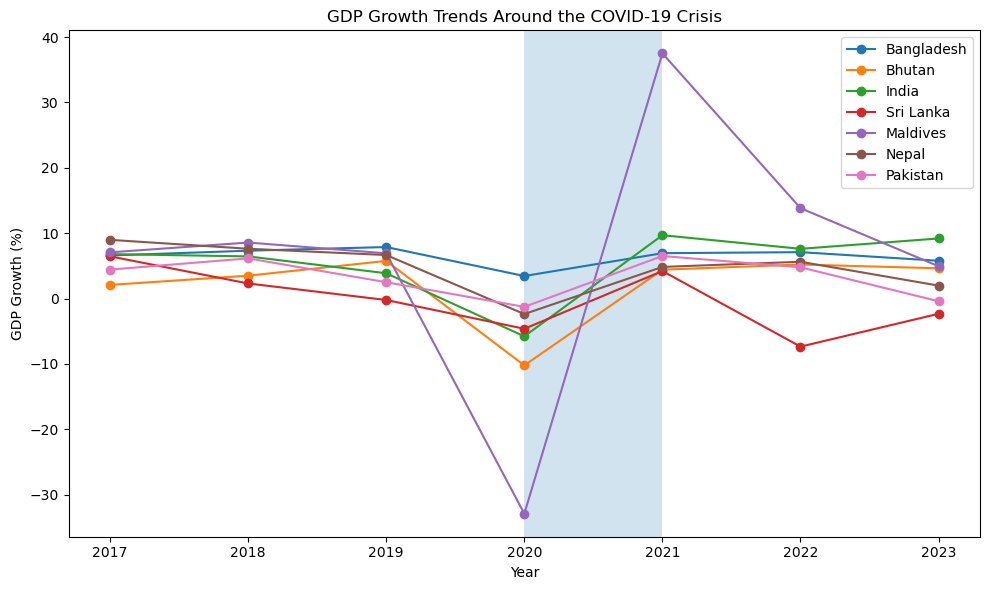

In [42]:
plt.figure(figsize=(10, 6))

for country in df_2020["country_name"].unique():
    sub = df_2020[df_2020["country_name"] == country]
    plt.plot(sub["year"], sub["gdp_growth_pct"], marker='o', label=country)

plt.axvspan(2020, 2021, alpha=0.2)

plt.title("GDP Growth Trends Around the COVID-19 Crisis")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")

plt.legend()
plt.tight_layout()

plt.savefig("images/gdp_growth_covid.png", dpi=300)

plt.show()

## Employment ratio

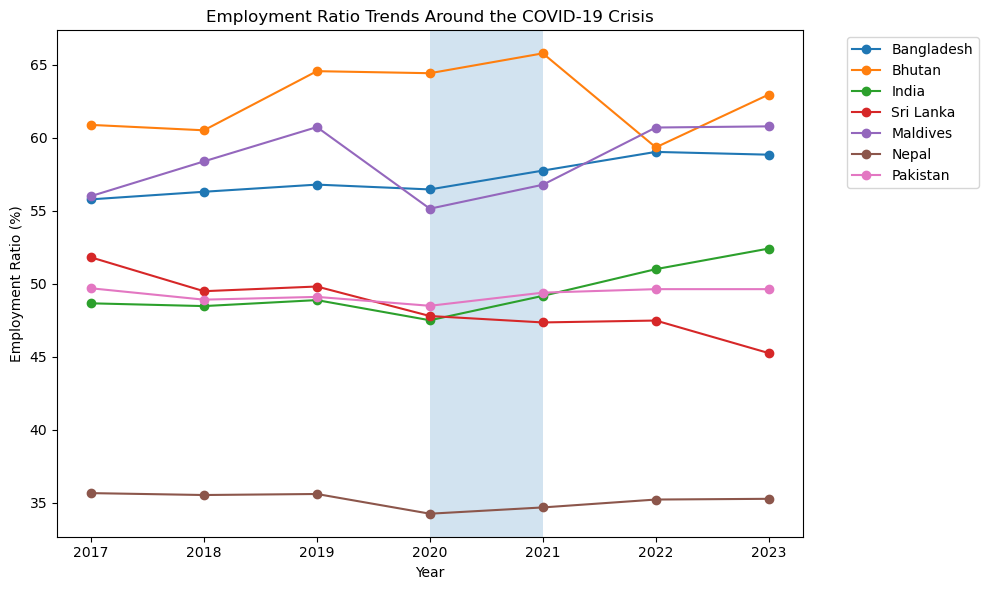

In [43]:
plt.figure(figsize=(10, 6))

for country in df_2020["country_name"].unique():
    sub = df_2020[df_2020["country_name"] == country]
    plt.plot(sub["year"], sub["employment_ratio"], marker='o', label=country)

plt.axvspan(2020, 2021, alpha=0.2)

plt.title("Employment Ratio Trends Around the COVID-19 Crisis")
plt.xlabel("Year")
plt.ylabel("Employment Ratio (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig("images/employment_ratio_covid.png", dpi=300)

plt.show()

## GDP per capita 

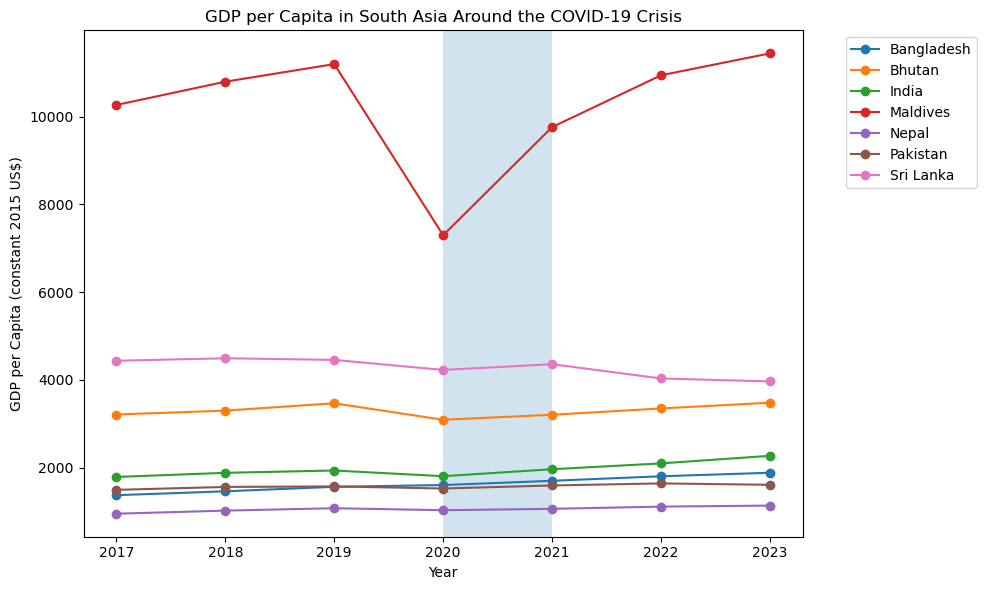

In [44]:
plt.figure(figsize=(10, 6))

for country in sorted(df_2020["country_name"].unique()):
    sub = df_2020[df_2020["country_name"] == country]
    plt.plot(sub["year"], sub["gdp_per_capita"], marker='o', label=country)

plt.axvspan(2020, 2021, alpha=0.2)

plt.title("GDP per Capita in South Asia Around the COVID-19 Crisis")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (constant 2015 US$)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig("images/gdp_per_capita_covid.png", dpi=300)

plt.show()

## Average by period

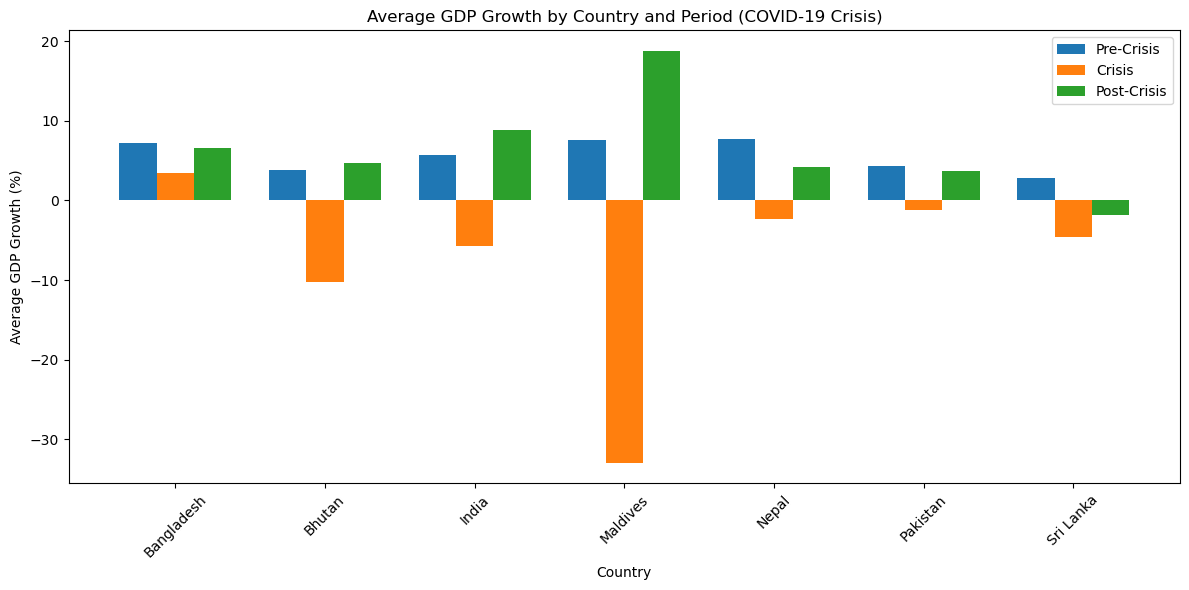

In [45]:
countries = country_period_avg["country_name"].unique()
periods = ["Pre-Crisis", "Crisis", "Post-Crisis"]

x = np.arange(len(countries))
width = 0.25

plt.figure(figsize=(12, 6))

for i, period in enumerate(periods):
    sub = country_period_avg[country_period_avg["period"] == period]
    
    sub = sub.set_index("country_name").reindex(countries).reset_index()
    
    plt.bar(x + i*width, sub["gdp_growth_pct"], width, label=period)

plt.xticks(x + width, countries, rotation=45)
plt.title("Average GDP Growth by Country and Period (COVID-19 Crisis)")
plt.xlabel("Country")
plt.ylabel("Average GDP Growth (%)")

plt.legend()
plt.tight_layout()

plt.savefig("images/gdp_bar_covid.png", dpi=300)

plt.show()